# Week 7 · 投机解码实战：一次教科书级的负结果

> 🎯 **本周实验**：给 vLLM 加上 N-gram 投机解码，寻找"交叉点"。
> **结果**：交叉点在我们的系统上低于 QPS=1——投机解码全线减速。
> 这个负结果比一次假加速有价值一百倍。

## 0. 一分钟理论

投机解码 = 小模型/算法"猜"k 个 token → 大模型一次前向并行验收 → 输出分布**数学上无损**。

**收益条件**（Week 1 roofline）：系统在带宽瓶颈区（算力免费）时白捡加速；在算力瓶颈区（高负载）时纯赔。
官方数据：低 QPS **+1.5~2.8×**，高 QPS **-1.4~1.8×** → 必然存在交叉点。

## 1. 实验配置

```bash
vllm serve ... --speculative-config \
  '{"method": "ngram", "num_speculative_tokens": 5, "prompt_lookup_max": 5}'
```

N-gram 方案：零下载零显存，从 prompt 里查重复片段当草稿（摘要/重复文本命中率极高）。

## 2. 实机数据（2026-09-08 · RTX 5090 · vLLM 0.28）

/tmp/ipykernel_1510/14476726.py:19: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/workspace/week07_spec.png", dpi=120); plt.show()
/tmp/ipykernel_1510/14476726.py:19: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/workspace/week07_spec.png", dpi=120); plt.show()
/tmp/ipykernel_1510/14476726.py:19: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/workspace/week07_spec.png", dpi=120); plt.show()
/tmp/ipykernel_1510/14476726.py:19: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("/workspace/week07_spec.png", dpi=120); plt.show()
/tmp/ipykernel_1510/14476726.py:19: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22797 (\N{CJK UNIFIED IDEOGRAPH-590D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/miniconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py

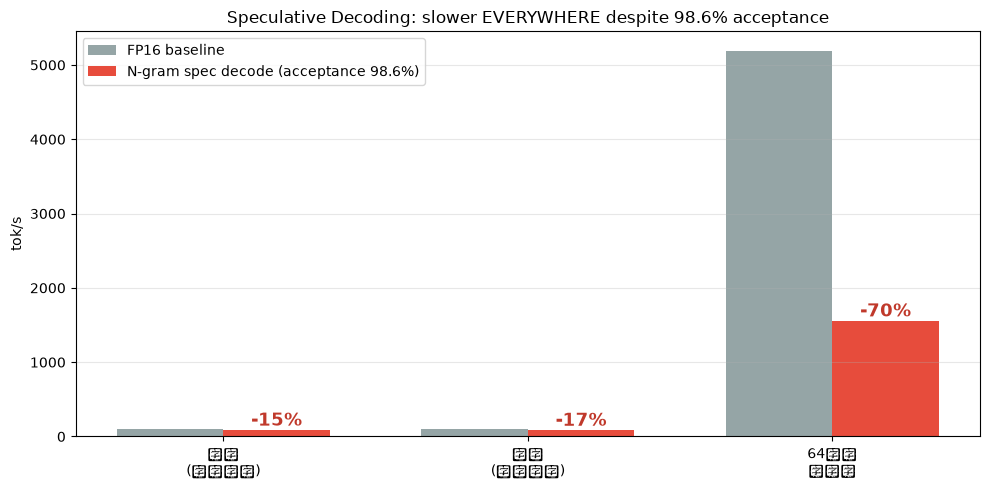

❌ 单流: -15%   ❌ 64并发: -70%
🤯 最反直觉：接受率 98.6%，依然全线减速！


In [1]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["单流\n(重复文本)", "单流\n(自然文本)", "64并发\n总吞吐"]
baseline = [104, 104, 5193]
spec     = [88, 86, 1558]
acceptance = 98.6  # % —— 草稿几乎全中！

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, baseline, w, label="FP16 baseline", color="#95a5a6")
b2 = ax.bar(x + w/2, spec, w, label=f"N-gram spec decode (acceptance {acceptance}%)", color="#e74c3c")
for i, (b, s) in enumerate(zip(baseline, spec)):
    ax.annotate(f"{s/b*100-100:+.0f}%", xy=(x[i]+w/2, s), ha="center", va="bottom",
                fontsize=13, fontweight="bold", color="#c0392b")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("tok/s")
ax.set_title("Speculative Decoding: slower EVERYWHERE despite 98.6% acceptance")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig("/workspace/week07_spec.png", dpi=120); plt.show()

print("❌ 单流: -15%   ❌ 64并发: -70%")
print("🤯 最反直觉：接受率 98.6%，依然全线减速！")

## 3. 为什么 100% 接受率还会慢？（三个 Regime 的闭环）

```
每步耗时 = GPU 验证(5+1 token) + CPU n-gram 查找
                ↓                      ↓
        几乎免费（算力闲置）     纯 Python 扫描，随上下文变长
                                且 ngram 模式禁用 async scheduling
                                → CPU 与 GPU 串行执行，无法重叠！
```

- GPU 每步只要 ~10ms，CPU 查找却要 50-60ms
- 瓶颈从 **带宽**（第二 regime）转移到 **开销**（第一 regime）
- Week 1 的三个 regime 理论，在真实系统上完成闭环 ✅

## 4. 工程结论

| 教训 | 说明 |
|---|---|
| 负结果也是成果 | 我们的交叉点 < QPS 1，这就是"找到自己的交叉点" |
| 草稿要 GPU 侧 | EAGLE/draft model 用 GPU 起草；CPU 起草（ngram）在此栈是坑 |
| 数字要重测 | 官方 2.8× 是旧版本+H100+摘要负载，换栈必重测 |
| 敢发负结果 | 比假加速有用一百倍 |

**生产正确姿势**：草稿用 GPU 侧方案 + 按负载动态开关（dynamic speculative decoding）。

## 5. 复现

```bash
bash /workspace/switch_spec.sh     # 切到投机解码模式
python3 /workspace/fp8_test.py     # 测速（对比 FP16 基线 104/5193）
curl localhost:8000/metrics | grep spec_decode   # 查接受率
```

## 6. 下一站

➡️ **Week 8 分离式服务**：prefill 和 decode 拆到不同 GPU——Week 1 的"两个阶段两种瓶颈"终于要变成架构了。